# HYBRID IR: BM25 + NMF (TF-IDF weighting) — Grid Search (alpha, k) và sweep n_components

**NMF = Non-negative Matrix Factorization:** phân rã ma trận term–doc $X \approx W H$ với ràng buộc $W, H \geq 0$.

- $W \in \mathbb{R}^{n_{docs} \times K}_+$: phân phối *trộn* của mỗi doc trên K "chủ đề ngầm" (không phải xác suất, nhưng không âm).
- $H \in \mathbb{R}^{K \times n_{terms}}_+$: cường độ của từ trong mỗi chủ đề.

**So với 3 notebook khác:**
- `lsa.ipynb`: TF-IDF (sublinear) → TruncatedSVD (chiều âm, khó diễn giải)
- `lsi.ipynb`: Log-Entropy → TruncatedSVD (Deerwester 1990)
- `lda.ipynb`: Count → LDA (xác suất, chậm)
- `nmf.ipynb` (file này): **TF-IDF → NMF** (không âm, topic diễn giải tốt, nhanh)

Mọi thứ còn lại (samples=20k, test queries, alpha-grid, k-grid, metrics, framework đánh giá) đều **giống cả 4 notebook** để dễ so sánh.

## 1. CÀI ĐẶT THƯ VIỆN

In [1]:
!pip install rank_bm25 datasets pyvi -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 42.8 MB/s eta 0:00:00


In [2]:
import os
import re
import time
import zipfile
import warnings

import numpy as np
import pandas as pd
import scipy.sparse as sp
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from pyvi import ViTokenizer
from rank_bm25 import BM25Okapi
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

## 2. CẤU HÌNH CHUNG (dùng giống nhau cho LSA / LSI / LDA / NMF)

In [3]:
MAX_SAMPLES    = 20000
RANDOM_STATE   = 42
ALPHA_GRID     = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
K_GRID         = [1, 3, 5, 10, 20]
N_COMP_GRID    = [50, 100, 200, 300]
DEFAULT_K      = 10
DEFAULT_N_COMP = 200
NMF_MAX_ITER   = 300
MODEL_NAME     = 'nmf'

TEST_QUERIES = [
    {'query': 'thời tiết mưa bão nhiệt độ dự báo',     'category': 'weather',       'keywords': ['thời tiết', 'mưa', 'bão', 'nhiệt độ', 'dự báo']},
    {'query': 'chứng khoán cổ phiếu thị trường đầu tư', 'category': 'stock',         'keywords': ['chứng khoán', 'cổ phiếu', 'thị trường', 'đầu tư']},
    {'query': 'bóng đá việt nam cầu thủ đội tuyển',     'category': 'sports',        'keywords': ['bóng đá', 'việt nam', 'cầu thủ', 'đội tuyển']},
    {'query': 'công nghệ AI trí tuệ nhân tạo máy học',  'category': 'tech',          'keywords': ['công nghệ', 'ai', 'trí tuệ', 'nhân tạo', 'máy học']},
    {'query': 'giá vàng hôm nay tăng mạnh',             'category': 'commodity',     'keywords': ['vàng', 'giá', 'tăng', 'thị trường']},
    {'query': 'dịch covid vaccine tiêm chủng',          'category': 'health',        'keywords': ['covid', 'vaccine', 'dịch', 'bệnh']},
    {'query': 'xe điện vinfast ô tô sản xuất',          'category': 'automotive',    'keywords': ['xe điện', 'vinfast', 'ô tô', 'sản xuất']},
    {'query': 'ca sĩ nhạc mới album âm nhạc',           'category': 'entertainment', 'keywords': ['ca sĩ', 'nhạc', 'album', 'âm nhạc']},
    {'query': 'tội phạm ma túy bắt giữ',                'category': 'crime',         'keywords': ['ma túy', 'tội phạm', 'bắt', 'giữ']},
    {'query': 'tai nạn giao thông xe hỏng',             'category': 'accident',      'keywords': ['tai nạn', 'giao thông', 'xe', 'hỏng']},
    {'query': 'thể thao olympic vàng huy chương',       'category': 'olympic',       'keywords': ['thể thao', 'olympic', 'vàng', 'huy chương']},
    {'query': 'du lịch resort khách sạn nghỉ dưỡng',    'category': 'travel',        'keywords': ['du lịch', 'resort', 'khách sạn', 'nghỉ dưỡng']},
    {'query': 'giáo dục trường học sinh viên',          'category': 'education',     'keywords': ['giáo dục', 'trường', 'học', 'sinh viên']},
    {'query': 'chính trị quốc tế tổng thống',           'category': 'politics',      'keywords': ['chính trị', 'quốc tế', 'tổng thống', 'chính phủ']},
    {'query': 'thời trang làm đẹp con gái',             'category': 'fashion',       'keywords': ['thời trang', 'làm đẹp', 'con gái', 'mỹ phẩm']},
]

np.random.seed(RANDOM_STATE)
print(f'Config: MODEL={MODEL_NAME} | N={MAX_SAMPLES} | |alpha|={len(ALPHA_GRID)} | |k|={len(K_GRID)} | |n_comp|={len(N_COMP_GRID)} | |Q|={len(TEST_QUERIES)}')

Config: MODEL=nmf | N=20000 | |alpha|=11 | |k|=5 | |n_comp|=4 | |Q|=15


## 3. TIỀN XỬ LÝ TIẾNG VIỆT

In [4]:
STOPWORDS = set([
    'và', 'của', 'một', 'những', 'các', 'được', 'có', 'là', 'cho', 'khi',
    'đã', 'sẽ', 'nếu', 'như', 'tại', 'vào', 'ra', 'mà', 'này', 'kia', 'đó',
    'ấy', 'thì', 'rằng', 'để', 'với', 'không', 'cũng', 'lại', 'rất', 'nên',
    'bị', 'do', 'về', 'theo', 'qua', 'trong', 'ngoài', 'trên', 'dưới', 'bởi',
    'cả', 'cùng', 'đang', 'đây', 'đến', 'đi', 'hơn', 'kể', 'lên', 'mới',
    'ngay', 'nữa', 'rồi', 'sau', 'thôi', 'thưa'
])
VI_CHARS = (
    'a-z0-9'
    'àáạảãâầấậẩẫăằắặẳẵ'
    'èéẹẻẽêềếệểễ'
    'ìíịỉĩ'
    'òóọỏõôồốộổỗơờớợởỡ'
    'ùúụủũưừứựửữ'
    'ỳýỵỷỹđ'
)
_RE_HTML  = re.compile(r'<[^>]+>')
_RE_URL   = re.compile(r'http\S+|www\S+|https\S+')
_RE_CHARS = re.compile(rf'[^{VI_CHARS}\s_]')
_RE_WS    = re.compile(r'\s+')

def preprocess_text(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = _RE_HTML.sub(' ', text)
    text = _RE_URL.sub(' ', text)
    text = ViTokenizer.tokenize(text).lower()
    text = _RE_CHARS.sub(' ', text)
    text = _RE_WS.sub(' ', text).strip()
    return ' '.join(t for t in text.split() if t not in STOPWORDS and len(t) > 1)

def minmax_norm(scores) -> np.ndarray:
    arr = np.asarray(scores, dtype=float)
    lo, hi = arr.min(), arr.max()
    return np.zeros_like(arr) if hi == lo else (arr - lo) / (hi - lo)

print('Preprocessing utilities ready.')

Preprocessing utilities ready.


## 4. TẢI VÀ TIỀN XỬ LÝ 20K TÀI LIỆU

In [5]:
print(f'Loading nam194/vietnews [:{MAX_SAMPLES}] ...')
t0 = time.time()
ds = load_dataset('nam194/vietnews', split=f'train[:{MAX_SAMPLES}]')
content_key = 'text' if 'text' in ds[0].keys() else 'article'

titles    = [item.get('title', '') for item in ds]
documents = [item.get(content_key, '') or item.get('abstract', '') for item in ds]
urls      = [item.get('url', 'N/A') for item in ds]
print(f'Loaded {len(documents)} docs in {time.time()-t0:.1f}s | content_key="{content_key}"')

Loading nam194/vietnews [:20000] ...


README.md:   0%|          | 0.00/748 [00:00<?, ?B/s]

data/train-00000-of-00001-84acb79f6c6547(…):   0%|          | 0.00/170M [00:00<?, ?B/s]

data/validation-00000-of-00001-210cc51bf(…):   0%|          | 0.00/38.3M [00:00<?, ?B/s]

data/test-00000-of-00001-123f98d55067eb7(…):   0%|          | 0.00/38.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/99134 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/22184 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/22498 [00:00<?, ? examples/s]

Loaded 20000 docs in 21.8s | content_key="article"


In [6]:
t0 = time.time()
processed_docs  = [preprocess_text(d) for d in documents]
tokenized_docs  = [d.split() for d in processed_docs]
documents_lower = [d.lower() for d in documents]
print(f'Preprocessed in {time.time()-t0:.1f}s | avg tokens/doc = {np.mean([len(t) for t in tokenized_docs]):.1f}')

Preprocessed in 151.5s | avg tokens/doc = 271.5


## 5. BM25 (LEXICAL BASELINE)

In [7]:
t0 = time.time()
bm25_model = BM25Okapi(tokenized_docs)
print(f'BM25 built in {time.time()-t0:.1f}s | vocab = {len(bm25_model.idf)}')

BM25 built in 1.6s | vocab = 87931


## 6. NMF = TF-IDF → NMF (Non-negative Matrix Factorization)

**Tại sao TF-IDF chứ không phải Count?** NMF yêu cầu ma trận đầu vào không âm — cả Count lẫn TF-IDF đều thoả. Nhưng TF-IDF đã trừ bớt trọng số term phổ biến → giúp NMF tìm topic *phân biệt* hơn. Đây cũng là khuyến nghị chuẩn trong sklearn docs.

**NMF khác SVD ở chỗ:**
- SVD: $X \approx U \Sigma V^T$ (U, V có thể âm) → khó diễn giải chiều ẩn.
- NMF: $X \approx W H$ với $W, H \geq 0$ → mỗi chiều là *cộng dồn* các từ, đọc top từ mỗi topic ra ý nghĩa luôn.

**Hàm mục tiêu:** Frobenius norm $\min \|X - WH\|_F^2$ (sklearn mặc định, hoặc Kullback-Leibler nếu thích).

Sweep `n_components` ∈ {50, 100, 200, 300}, init='nndsvd' (deterministic, nhanh hơn random).

In [8]:
t0 = time.time()
tfidf_vectorizer = TfidfVectorizer(
    token_pattern=r'(?u)\b\w+\b',
    max_features=10000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
)
tfidf_matrix = tfidf_vectorizer.fit_transform(processed_docs)
print(f'TF-IDF: {tfidf_matrix.shape} | nnz={tfidf_matrix.nnz} | {time.time()-t0:.1f}s')

TF-IDF: (20000, 10000) | nnz=2907389 | 5.2s


In [9]:
nmf_variants = {}
for nc in N_COMP_GRID:
    t0 = time.time()
    nmf = NMF(
        n_components=nc,
        init='nndsvd',
        solver='cd',
        beta_loss='frobenius',
        max_iter=NMF_MAX_ITER,
        tol=1e-4,
        random_state=RANDOM_STATE,
    )
    W = nmf.fit_transform(tfidf_matrix)  # (n_docs, nc)
    recon_err = float(nmf.reconstruction_err_)
    nmf_variants[nc] = {
        'model':         nmf,
        'doc_topic':     W,
        'doc_topic_norm': normalize(W),
        'recon_err':     recon_err,
        'n_iter':        int(nmf.n_iter_),
        'fit_seconds':   time.time() - t0,
    }
    print(f'  n_components={nc:>3} | recon_err={recon_err:.2f} | iters={nmf.n_iter_} | {nmf_variants[nc]["fit_seconds"]:.1f}s')

nmf_model       = nmf_variants[DEFAULT_N_COMP]['model']
doc_topic_dist  = nmf_variants[DEFAULT_N_COMP]['doc_topic']
doc_topic_norm  = nmf_variants[DEFAULT_N_COMP]['doc_topic_norm']

  n_components= 50 | recon_err=128.82 | iters=300 | 88.8s
  n_components=100 | recon_err=125.82 | iters=229 | 203.6s
  n_components=200 | recon_err=121.58 | iters=300 | 779.5s
  n_components=300 | recon_err=118.32 | iters=266 | 1431.7s


In [10]:
def display_topics(model, vectorizer, n_topics_show=8, n_words=8):
    feat = vectorizer.get_feature_names_out()
    for idx in range(min(n_topics_show, model.components_.shape[0])):
        topic = model.components_[idx]
        top = topic.argsort()[-n_words:][::-1]
        print(f'Topic {idx}: ' + ', '.join(f'{feat[i]}({topic[i]:.2f})' for i in top))

display_topics(nmf_model, tfidf_vectorizer)

Topic 0: vụ_việc(2.67), rõ(1.39), xảy(1.02), sự_việc(0.97), điều_tra(0.96), làm(0.83), cơ_quan_chức_năng(0.82), hiện(0.78)
Topic 1: luôn(1.87), mình(1.81), mọi(1.47), cuộc_sống(1.45), hạnh_phúc(1.43), bản_thân(1.17), điều(1.10), chia_sẻ(1.08)
Topic 2: ubnd(25.31), chủ_tịch(13.80), phó_chủ_tịch(7.98), chỉ_đạo(3.99), lãnh_đạo(2.74), nguyễn_thành_phong(2.38), báo_cáo(2.38), hđnd(2.06)
Topic 3: tai_nạn(113.14), vụ(55.22), hiện_trường(47.28), va_chạm(43.95), tông(39.14), bị_thương(34.64), xe_máy(33.57), xảy(29.92)
Topic 4: ma_tuý(1.42), trái_phép(0.75), chất(0.71), tàng_trữ(0.37), thu_giữ(0.37), mua_bán(0.35), heroin(0.33), quả_tang(0.32)
Topic 5: lũ(1.12), mưa_lũ(0.47), cuốn(0.34), ngập(0.32), trôi(0.30), chia_cắt(0.20), dâng(0.19), vùng(0.19)
Topic 6: bão(14.16), thiên_tai(7.47), phòng_chống(6.11), ứng_phó(6.01), tàu_thuyền(5.42), cơn(4.28), tránh(3.66), đổ_bộ(3.38)
Topic 7: cục(1.59), tổng_cục(0.41), việt_nam(0.40), cục_trưởng(0.39), phó_cục_trưởng(0.23), quản_lý(0.20), đường_bộ(0.17), b

## 7. HÀM TÌM KIẾM HYBRID — TỐI ƯU

$$\text{score}(d,q) = \alpha \cdot \widetilde{BM25}(d,q) + (1-\alpha) \cdot \widetilde{NMF}(d,q)$$

NMF score = cosine similarity giữa biểu diễn topic của query (chiếu qua `nmf.transform`) và biểu diễn topic của document (đã L2-normalize).

In [11]:
def project_query_nmf(query_pre: str, nmf, vectorizer):
    """Vector hoá query theo TF-IDF rồi chiếu sang không gian NMF, L2-normalize."""
    q_tfidf = vectorizer.transform([query_pre])
    q_topic = nmf.transform(q_tfidf)
    return normalize(q_topic)

def compute_query_scores(query: str, dt_norm: np.ndarray, nmf, vectorizer=None):
    vectorizer = vectorizer or tfidf_vectorizer
    pq = preprocess_text(query)
    tokens = pq.split()
    if not tokens:
        n = dt_norm.shape[0]
        return np.zeros(n), np.zeros(n)
    bm25_raw = bm25_model.get_scores(tokens)
    q_topic  = project_query_nmf(pq, nmf, vectorizer)
    sem_raw  = cosine_similarity(q_topic, dt_norm).flatten()
    return minmax_norm(bm25_raw), minmax_norm(sem_raw)

def top_k_indices(scores: np.ndarray, k: int) -> np.ndarray:
    k = min(k, scores.shape[0])
    part = np.argpartition(-scores, k - 1)[:k]
    return part[np.argsort(-scores[part])]

def search_hybrid(query: str, alpha: float = 0.5, top_k: int = DEFAULT_K, nmf=None, dt_norm=None):
    nmf = nmf or nmf_model
    dt_norm = doc_topic_norm if dt_norm is None else dt_norm
    bm_n, sem_n = compute_query_scores(query, dt_norm, nmf)
    final = alpha * bm_n + (1.0 - alpha) * sem_n
    idx = top_k_indices(final, top_k)
    return idx.tolist(), final[idx].tolist(), {
        'bm25_scores': {int(i): float(bm_n[i]) for i in idx},
        'nmf_scores':  {int(i): float(sem_n[i]) for i in idx},
    }

_idx, _scr, _ = search_hybrid('giá vàng tăng', alpha=0.5, top_k=3)
for i, s in zip(_idx, _scr):
    print(f'{s:.4f}\t{titles[i][:80]}')

0.8881	Giá vàng tăng gần 41 triệu đồng / lượng giữa căng_thẳng Mỹ - Trung
0.8458	Người_dân Vũng_Tàu chen nhau mua vàng , heo quay
0.7843	Vía_Thần tài , Hà_Nội đội mưa từ 4h sáng mua vàng


## 8. PRE-COMPUTE GROUND-TRUTH RELEVANCE

In [12]:
def build_relevance(test_queries, docs_lower, min_hits: int = 2):
    rel = []
    for tq in test_queries:
        kws = [k.lower() for k in tq['keywords']]
        mask = np.zeros(len(docs_lower), dtype=bool)
        for i, dl in enumerate(docs_lower):
            if sum(1 for k in kws if k in dl) >= min_hits:
                mask[i] = True
        rel.append({'mask': mask, 'total': int(mask.sum())})
    return rel

t0 = time.time()
RELEVANCE = build_relevance(TEST_QUERIES, documents_lower)
print(f'Relevance built in {time.time()-t0:.1f}s | counts = {[r["total"] for r in RELEVANCE]}')

Relevance built in 3.1s | counts = [357, 0, 0, 4, 2602, 386, 0, 149, 3408, 607, 6, 1, 2591, 0, 0]


## 9. GRID SEARCH (alpha × k) — 6 METRICS

In [13]:
def ndcg_at_k(rels, k):
    rels = rels[:k]
    dcg  = sum((2**r - 1) / np.log2(i + 2) for i, r in enumerate(rels))
    idcg = sum((2**r - 1) / np.log2(i + 2) for i, r in enumerate(sorted(rels, reverse=True)))
    return dcg / idcg if idcg > 0 else 0.0

def average_precision(rels):
    hits, ap = 0, 0.0
    for i, r in enumerate(rels):
        if r:
            hits += 1
            ap += hits / (i + 1)
    return ap / hits if hits > 0 else 0.0

def reciprocal_rank(rels):
    for i, r in enumerate(rels):
        if r:
            return 1.0 / (i + 1)
    return 0.0

def query_metrics(ranked_idx, rel_info, k):
    rels = [int(rel_info['mask'][i]) for i in ranked_idx[:k]]
    tp = sum(rels)
    p = tp / k
    r = tp / rel_info['total'] if rel_info['total'] > 0 else 0.0
    return {
        'precision': p, 'recall': r,
        'f1':  2*p*r/(p+r) if (p+r) > 0 else 0.0,
        'map': average_precision(rels),
        'mrr': reciprocal_rank(rels),
        'ndcg': ndcg_at_k(rels, k),
    }

In [14]:
METRIC_KEYS = ['precision', 'recall', 'f1', 'map', 'mrr', 'ndcg']

def grid_search(alpha_grid, k_grid, nmf=None, dt_norm=None):
    nmf = nmf or nmf_model
    dt_norm = doc_topic_norm if dt_norm is None else dt_norm
    cached = [compute_query_scores(tq['query'], dt_norm, nmf) for tq in TEST_QUERIES]
    out = {a: {k: {m: 0.0 for m in METRIC_KEYS} for k in k_grid} for a in alpha_grid}
    for a in alpha_grid:
        for k in k_grid:
            acc = {m: [] for m in METRIC_KEYS}
            for q_idx, (bm_n, sem_n) in enumerate(cached):
                final = a * bm_n + (1.0 - a) * sem_n
                ranked = top_k_indices(final, k)
                qm = query_metrics(ranked, RELEVANCE[q_idx], k)
                for m in METRIC_KEYS:
                    acc[m].append(qm[m])
            out[a][k] = {m: float(np.mean(v)) for m, v in acc.items()}
    return out

t0 = time.time()
grid_results = grid_search(ALPHA_GRID, K_GRID)
print(f'Grid {len(ALPHA_GRID)}x{len(K_GRID)} done in {time.time()-t0:.1f}s')

Grid 11x5 done in 2.4s


In [15]:
def grid_to_df(grid, metric):
    rows = [{'alpha': a, **{f'k={k}': grid[a][k][metric] for k in K_GRID}} for a in ALPHA_GRID]
    return pd.DataFrame(rows).set_index('alpha').round(4)

for m in METRIC_KEYS:
    print(f'\n=== {m.upper()} ===')
    print(grid_to_df(grid_results, m).to_string())

ndcg_tbl = grid_to_df(grid_results, 'ndcg')
best_alpha, best_k_label = ndcg_tbl.stack().idxmax()
best_k = int(best_k_label.split('=')[1])
print(f'\n>>> Best NDCG: alpha={best_alpha}, k={best_k} (value={ndcg_tbl.stack().max():.4f})')


=== PRECISION ===
          k=1     k=3     k=5    k=10    k=20
alpha                                        
0.0    0.2667  0.2444  0.2400  0.2133  0.2100
0.1    0.2667  0.2889  0.2533  0.2467  0.2400
0.2    0.3333  0.3111  0.2800  0.2600  0.2533
0.3    0.4000  0.3333  0.3067  0.2733  0.2733
0.4    0.4000  0.3556  0.3333  0.2800  0.2833
0.5    0.4000  0.3778  0.3467  0.3133  0.3167
0.6    0.5333  0.4222  0.4133  0.3533  0.3367
0.7    0.5333  0.4667  0.4400  0.3600  0.3567
0.8    0.5333  0.4667  0.4267  0.4000  0.3700
0.9    0.5333  0.4667  0.4400  0.3867  0.3900
1.0    0.5333  0.4667  0.4400  0.4000  0.4000

=== RECALL ===
          k=1     k=3     k=5    k=10    k=20
alpha                                        
0.0    0.0003  0.0012  0.0019  0.0035  0.0076
0.1    0.0003  0.0015  0.0019  0.0043  0.0097
0.2    0.0005  0.0015  0.0028  0.0050  0.0107
0.3    0.0010  0.0016  0.0030  0.0055  0.0119
0.4    0.0010  0.0024  0.0039  0.0060  0.0123
0.5    0.0010  0.0026  0.0150  0.0183  0.0635

## 10. SO SÁNH n_components CỦA NMF

In [16]:
ncomp_results = {}
for nc, info in nmf_variants.items():
    res = grid_search(ALPHA_GRID, [DEFAULT_K], nmf=info['model'], dt_norm=info['doc_topic_norm'])
    a_star = max(ALPHA_GRID, key=lambda a: res[a][DEFAULT_K]['ndcg'])
    ncomp_results[nc] = {
        'best_alpha': a_star,
        'best_ndcg':  res[a_star][DEFAULT_K]['ndcg'],
        'best_map':   res[a_star][DEFAULT_K]['map'],
        'recon_err':  info['recon_err'],
        'fit_secs':   info['fit_seconds'],
    }
ncomp_df = pd.DataFrame(ncomp_results).T
ncomp_df.index.name = 'n_components'
print(ncomp_df.round(4).to_string())

              best_alpha  best_ndcg  best_map  recon_err   fit_secs
n_components                                                       
50                   0.9     0.5512    0.5131   128.8165    88.7727
100                  1.0     0.5416    0.4977   125.8153   203.5624
200                  0.9     0.5524    0.5138   121.5844   779.4879
300                  0.8     0.5541    0.5175   118.3174  1431.6943


## 11. TRỰC QUAN HÓA

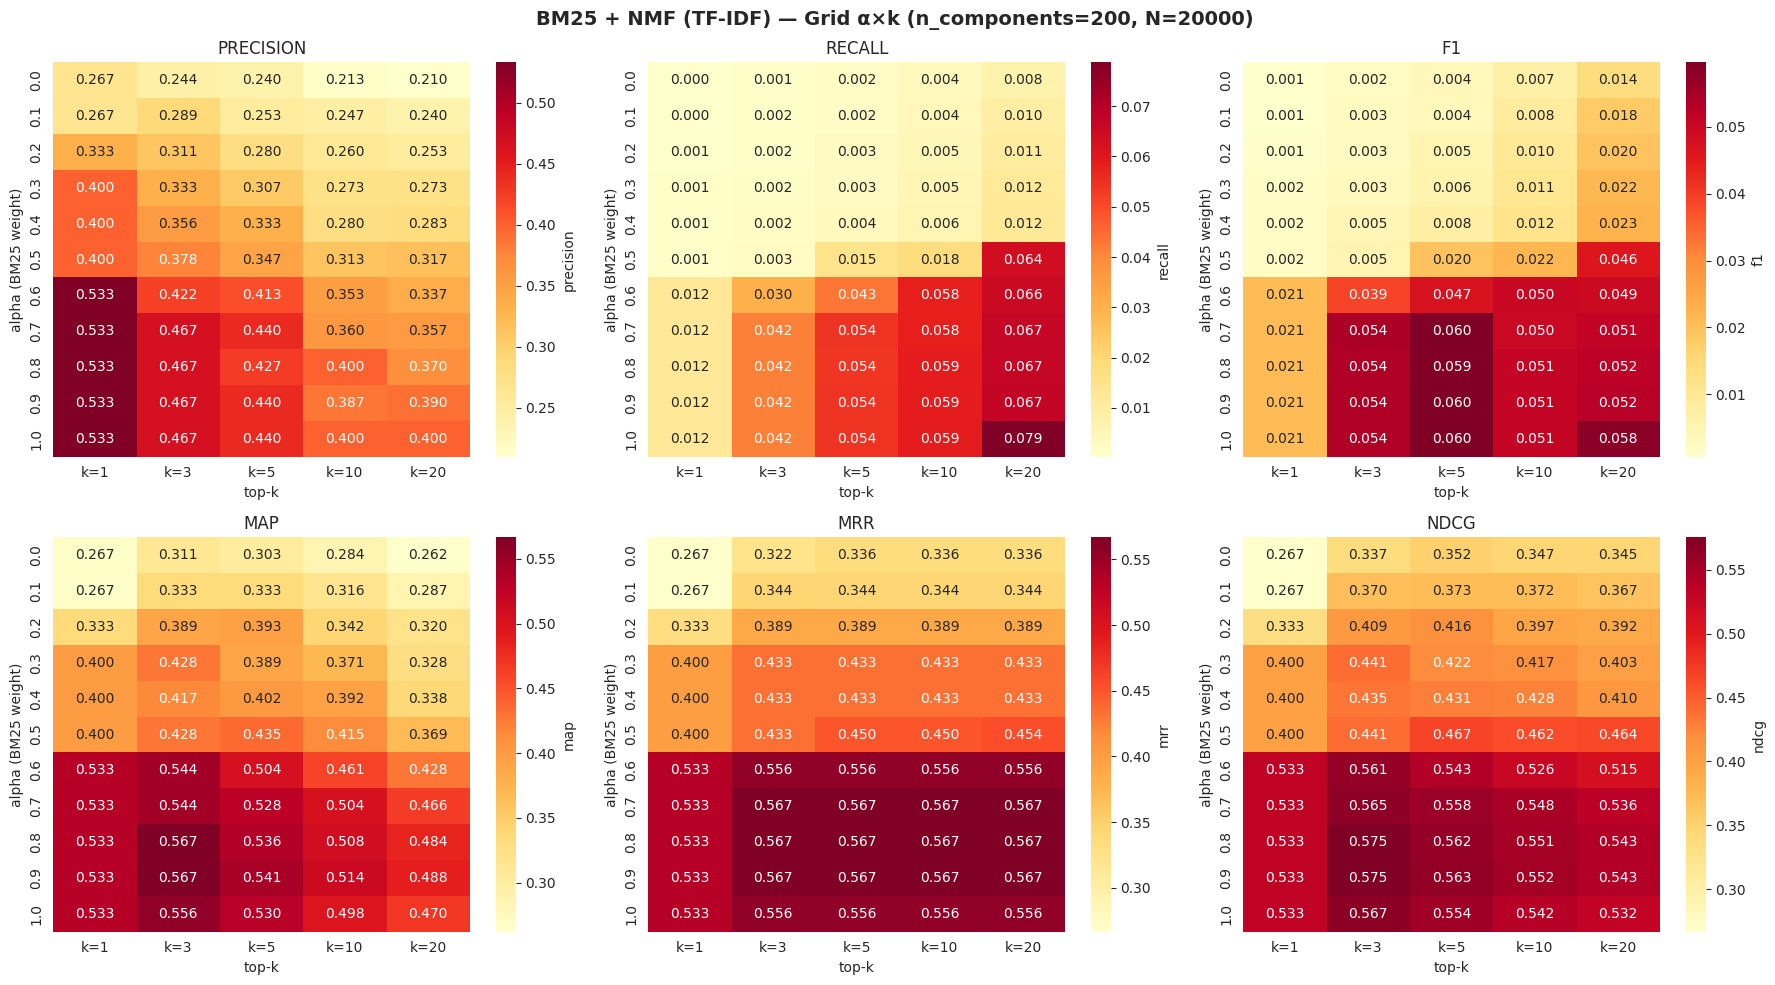

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'BM25 + NMF (TF-IDF) — Grid α×k (n_components={DEFAULT_N_COMP}, N={MAX_SAMPLES})',
             fontsize=14, fontweight='bold')
for ax, m in zip(axes.flat, METRIC_KEYS):
    sns.heatmap(grid_to_df(grid_results, m), annot=True, fmt='.3f', cmap='YlOrRd', ax=ax, cbar_kws={'label': m})
    ax.set_title(m.upper())
    ax.set_xlabel('top-k')
    ax.set_ylabel('alpha (BM25 weight)')
plt.tight_layout()
plt.show()

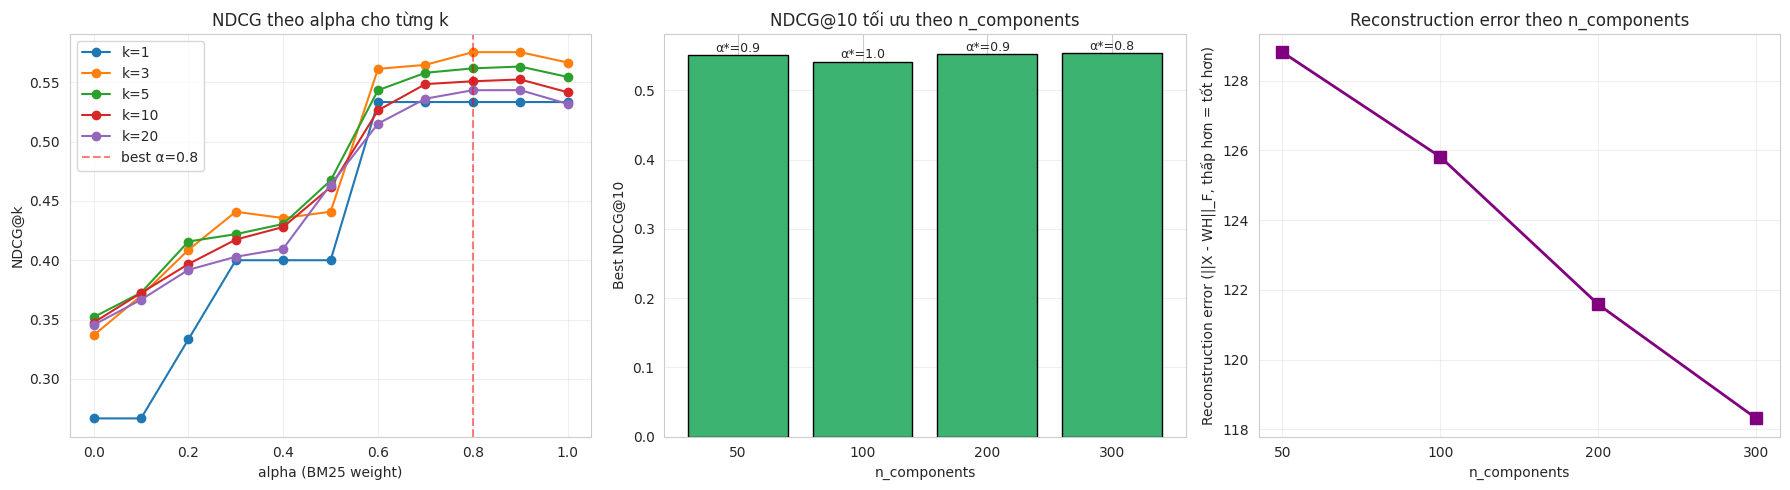

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
for k in K_GRID:
    vals = [grid_results[a][k]['ndcg'] for a in ALPHA_GRID]
    ax.plot(ALPHA_GRID, vals, marker='o', label=f'k={k}')
ax.axvline(best_alpha, color='red', linestyle='--', alpha=0.5, label=f'best α={best_alpha}')
ax.set_xlabel('alpha (BM25 weight)'); ax.set_ylabel('NDCG@k')
ax.set_title('NDCG theo alpha cho từng k'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.bar(ncomp_df.index.astype(str), ncomp_df['best_ndcg'], color='mediumseagreen', edgecolor='black')
for i, (nc, row) in enumerate(ncomp_df.iterrows()):
    ax.text(i, row['best_ndcg'] + 0.005, f"α*={row['best_alpha']}", ha='center', fontsize=9)
ax.set_xlabel('n_components'); ax.set_ylabel('Best NDCG@10')
ax.set_title('NDCG@10 tối ưu theo n_components'); ax.grid(True, alpha=0.3, axis='y')

ax = axes[2]
ax.plot(ncomp_df.index.astype(str), ncomp_df['recon_err'], marker='s', linewidth=2, markersize=8, color='purple')
ax.set_xlabel('n_components'); ax.set_ylabel('Reconstruction error (||X - WH||_F, thấp hơn = tốt hơn)')
ax.set_title('Reconstruction error theo n_components'); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

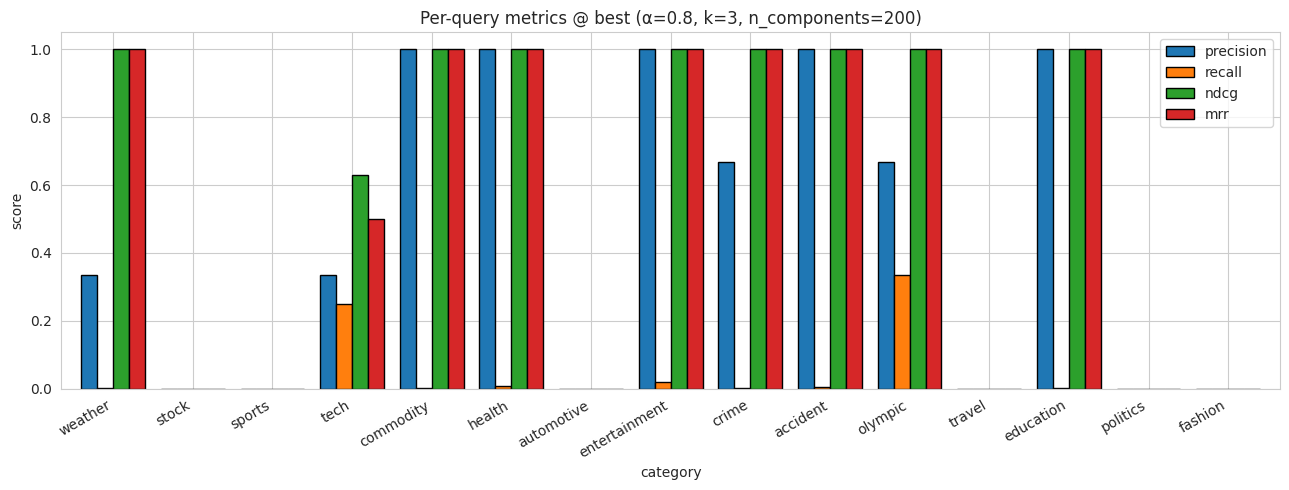

     category                               query  precision  recall     f1  map  mrr   ndcg
      weather   thời tiết mưa bão nhiệt độ dự báo     0.3333  0.0028 0.0056  1.0  1.0 1.0000
        stock chứng khoán cổ phiếu thị trường đầu     0.0000  0.0000 0.0000  0.0  0.0 0.0000
       sports  bóng đá việt nam cầu thủ đội tuyển     0.0000  0.0000 0.0000  0.0  0.0 0.0000
         tech công nghệ AI trí tuệ nhân tạo máy h     0.3333  0.2500 0.2857  0.5  0.5 0.6309
    commodity          giá vàng hôm nay tăng mạnh     1.0000  0.0012 0.0023  1.0  1.0 1.0000
       health       dịch covid vaccine tiêm chủng     1.0000  0.0078 0.0154  1.0  1.0 1.0000
   automotive       xe điện vinfast ô tô sản xuất     0.0000  0.0000 0.0000  0.0  0.0 0.0000
entertainment        ca sĩ nhạc mới album âm nhạc     1.0000  0.0201 0.0395  1.0  1.0 1.0000
        crime             tội phạm ma túy bắt giữ     0.6667  0.0006 0.0012  1.0  1.0 1.0000
     accident          tai nạn giao thông xe hỏng     1.0000  0.0049 0

In [19]:
rows = []
for q_idx, tq in enumerate(TEST_QUERIES):
    bm_n, sem_n = compute_query_scores(tq['query'], doc_topic_norm, nmf_model)
    final = best_alpha * bm_n + (1.0 - best_alpha) * sem_n
    ranked = top_k_indices(final, best_k)
    m = query_metrics(ranked, RELEVANCE[q_idx], best_k)
    rows.append({'category': tq['category'], 'query': tq['query'][:35], **m})
per_query_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(13, 5))
per_query_df.set_index('category')[['precision', 'recall', 'ndcg', 'mrr']].plot(
    kind='bar', ax=ax, width=0.8, edgecolor='black')
ax.set_title(f'Per-query metrics @ best (α={best_alpha}, k={best_k}, n_components={DEFAULT_N_COMP})')
ax.set_ylabel('score'); ax.set_xlabel('category')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()
print(per_query_df.round(4).to_string(index=False))

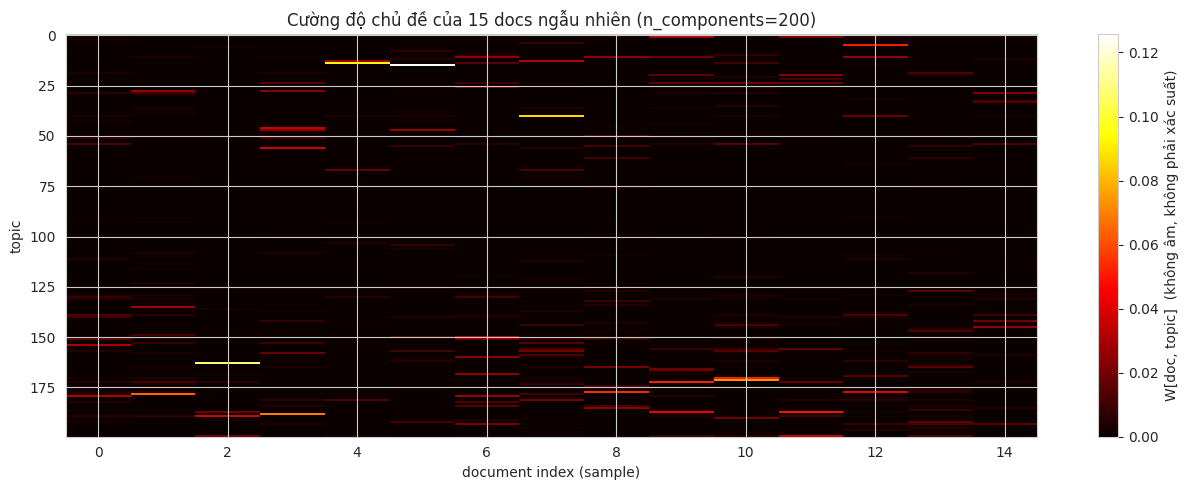

In [20]:
fig, ax = plt.subplots(figsize=(13, 5))
sample_ids = np.random.choice(doc_topic_dist.shape[0], size=15, replace=False)
im = ax.imshow(doc_topic_dist[sample_ids].T, aspect='auto', cmap='hot', interpolation='nearest')
ax.set_xlabel('document index (sample)')
ax.set_ylabel('topic')
ax.set_title(f'Cường độ chủ đề của 15 docs ngẫu nhiên (n_components={DEFAULT_N_COMP})')
plt.colorbar(im, ax=ax, label='W[doc, topic]  (không âm, không phải xác suất)')
plt.tight_layout()
plt.show()

## 12. LƯU MÔ HÌNH

In [21]:
MODEL_DIR = './saved_models'
os.makedirs(MODEL_DIR, exist_ok=True)
zip_path = os.path.join(MODEL_DIR, f'{MODEL_NAME}_models.zip')

artifacts = {
    'bm25_model.pkl':       bm25_model,
    'tfidf_vectorizer.pkl': tfidf_vectorizer,
    'nmf_model.pkl':        nmf_model,
    'doc_topic_dist.pkl':   doc_topic_dist,
    'tokenized_docs.pkl':   tokenized_docs,
    'documents.pkl':        documents,
    'titles.pkl':           titles,
    'urls.pkl':             urls,
    'grid_results.pkl':     grid_results,
    'config.pkl': {
        'model_name': MODEL_NAME, 'n_samples': MAX_SAMPLES,
        'best_alpha': best_alpha, 'best_k': best_k,
        'default_n_comp': DEFAULT_N_COMP,
    },
}

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for name, obj in artifacts.items():
        joblib.dump(obj, name)
        zf.write(name, name)
        os.remove(name)
print(f'Saved {len(artifacts)} artifacts to {zip_path}')

Saved 10 artifacts to ./saved_models/nmf_models.zip


## 13. DEMO TOP-K VỚI CẤU HÌNH TỐI ƯU

In [22]:
DEMO_QUERIES = ['thời tiết hôm nay', 'giá vàng thị trường', 'bóng đá việt nam', 'công nghệ trí tuệ nhân tạo']
for q in DEMO_QUERIES:
    indices, scores, details = search_hybrid(q, alpha=best_alpha, top_k=best_k)
    print(f'\n>>> "{q}" (α={best_alpha}, k={best_k})')
    for rank, (idx, score) in enumerate(zip(indices, scores), 1):
        bm = details['bm25_scores'].get(idx, 0.0)
        nm = details['nmf_scores'].get(idx, 0.0)
        print(f'  {rank}. [{score:.3f}] BM25={bm:.3f} NMF={nm:.3f} | {titles[idx][:80]}')


>>> "thời tiết hôm nay" (α=0.8, k=3)
  1. [0.844] BM25=0.908 NMF=0.585 | Nhiều dự_báo khác nhau về đợt áp_thấp_nhiệt_đới trên Biển_Đông
  2. [0.834] BM25=0.841 NMF=0.805 | Cần_Giờ không có thiệt_hại về người trong bão
  3. [0.805] BM25=1.000 NMF=0.025 | Thời_tiết phức_tạp , trường_học ở TP. HCM được chủ_động cho học_sinh nghỉ

>>> "giá vàng thị trường" (α=0.8, k=3)
  1. [0.945] BM25=1.000 NMF=0.723 | Giá vàng tăng gần 41 triệu đồng / lượng giữa căng_thẳng Mỹ - Trung
  2. [0.831] BM25=0.937 NMF=0.405 | Dầu , vàng khó bị ảnh_hưởng nếu Syria không căng
  3. [0.819] BM25=0.835 NMF=0.758 | Bệnh_viện , rạp hát cũ ở Biên_Hoà vào bảng ' đất vàng ' đấu_giá

>>> "bóng đá việt nam" (α=0.8, k=3)
  1. [0.966] BM25=0.988 NMF=0.877 | Thủ_tướng gửi thư chúc_mừng đội_tuyển U -23 Việt_Nam
  2. [0.963] BM25=0.963 NMF=0.961 | Hotgirl Thanh_Bi " chơi_trội " hứa làm điều đặc_biệt nếu Việt_Nam vô_địch
  3. [0.955] BM25=0.966 NMF=0.908 | Mỹ_Tâm " phá đảo thế_giới ảo " với màn ra đường " đi bão " không_thể độ